<a href="https://colab.research.google.com/github/sofibarbeito/INESDI_Data-Science_ML_IA/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio:**  
“Queremos identificar qué pedidos tienen mayor probabilidad de generar pérdidas, predecir el beneficio esperado de cada operación y segmentar los pedidos para diseñar estrategias comerciales más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [66]:
# Qué problema (o problemas) de negocio quieres resolver?
# Queremos identificar qué pedidos tienen mayor probabilidad de generar pérdidas, predecir el beneficio esperado de cada operación y segmentar los pedidos para diseñar estrategias comerciales más eficaces


# Fase 1 - EDA y primeros modelos


In [67]:
# Imports - añade aquí las librerías que vayas a utilizar en el notebook
import matplotlib.pyplot as plt
import seaborn as sns
# import pandas as pd
# import numpy as np
import pandas as pd
import numpy as np
# from sklearn.linear_model import LogisticRegression
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
# etc
import warnings
warnings.filterwarnings("ignore")

In [68]:
# Carga aquí tus datos - puedes elegir el dataset propuesto u otro de tu
# elección.

# Install kagglehub (si no está instalado)
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

# Ver qué archivos hay dentro
print(os.listdir(path))

# Cargar el dataset
df = pd.read_csv(os.path.join(path, "Sample - Superstore.csv"), encoding="latin1")

df.head()



Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final
['Sample - Superstore.csv']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


In [69]:
# Desarrolla tu código de EDA y preparación de
#El dataset Superstore contiene información sobre pedidos realizados en una cadena de tiendas de retail. Incluye variables relacionadas con clientes, productos, localización geográfica, ventas, descuentos y beneficios.
#El conjunto de datos contiene aproximadamente 9.994 registros de pedidos, lo que permite analizar el comportamiento de compra de los clientes y la rentabilidad de las operaciones.
#Este dataset ha sido elegido porque:
#Representa un caso realista del sector retail.
#Permite abordar diferentes problemas de Machine Learning, como clasificación, regresión y clustering.
#Contiene variables relevantes para el análisis de negocio, como ventas, descuentos, categorías de producto y beneficios.
#El objetivo es analizar los factores que influyen en la rentabilidad de las ventas y el comportamiento de compra de los clientes para mejorar las decisiones comerciales.#

# Idenificación de variables, tipos, nulos y duplicados
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [70]:
df.shape

(9994, 21)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [72]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [73]:
#Comprobación de valores nulos
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [74]:
#Comprobación de duplicados
df.duplicated().sum()

np.int64(0)

In [75]:
#El dataset contiene variables numéricas y categóricas.

#Las variables numéricas principales son:

#Sales

#Quantity

#Discount

#Profit

#Las variables categóricas incluyen:

#Segment

#Region

#Category

#Sub-Category

#Ship Mode

#No se detectan valores nulos relevantes  y el número de duplicados es inexistente.

In [76]:
#Limpieza de datos
df = df.drop_duplicates()

#Convertir fechas
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [77]:
#Creación de nuevas variables
#Tiempo de envío
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
#Variable Target de Pérdidas
df["Loss"] = df["Profit"].apply(lambda x: 1 if x < 0 else 0)

In [78]:
#Encoding
df_encoded = pd.get_dummies(df, columns=["Segment","Region","Category","Ship Mode"], drop_first=True)
#Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["Sales","Quantity","Discount","Shipping Time"]

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

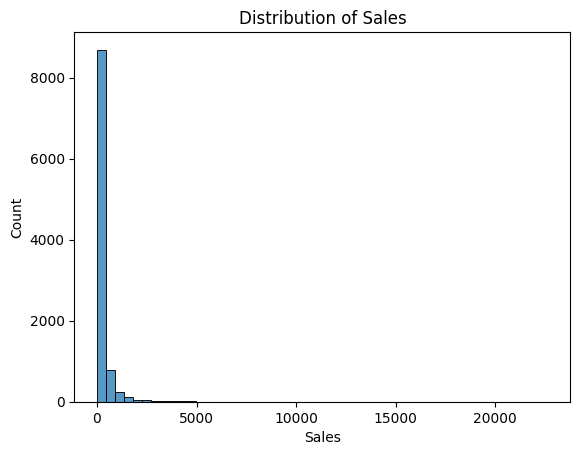

In [79]:
#Gráficos
#Distribución de ventas
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Sales"], bins=50)
plt.title("Distribution of Sales")
plt.show()

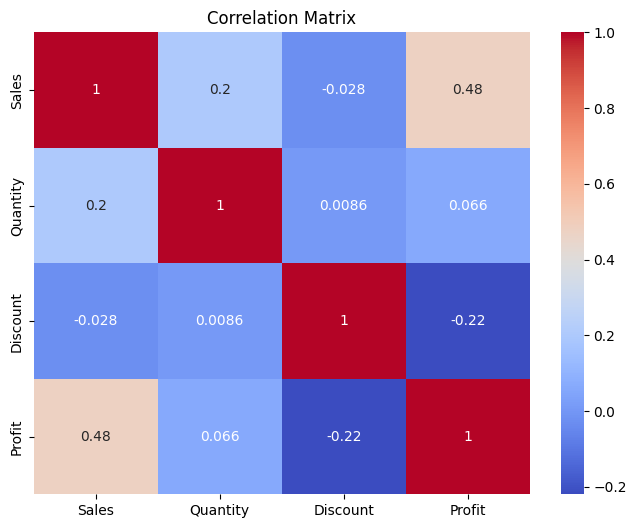

In [80]:
#Matriz de correlación
plt.figure(figsize=(8,6))
sns.heatmap(df[["Sales","Quantity","Discount","Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

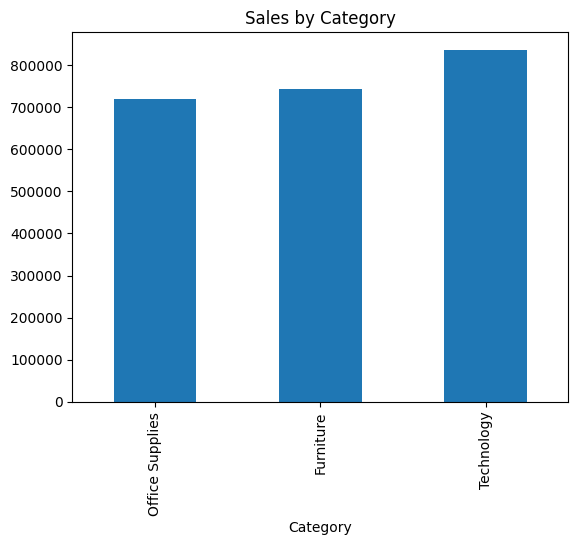

In [81]:
#Top categorías por ventas
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

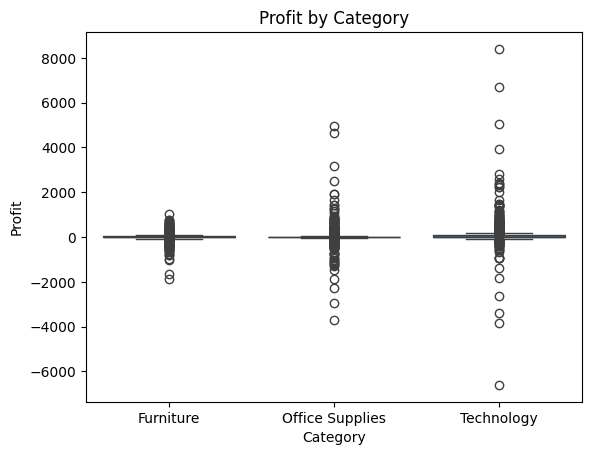

In [82]:
#Boxplot por categoría
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit by Category")
plt.show()

In [83]:
Con todo el contexto del EDA, aquí tienes el punto 7:

python
# -------------------------------------------------------
# 7. Explicaciones y decisiones en función de los resultados
#    (punto de vista de negocio)
# -------------------------------------------------------

# DISTRIBUCIÓN DE VENTAS:
# La distribución de Sales es fuertemente asimétrica hacia la derecha,
# con la mayoría de pedidos concentrados en valores bajos y pocos pedidos
# con ventas muy altas. Desde negocio, esto indica que un pequeño número
# de clientes o pedidos genera una parte desproporcionada del volumen total.
# Decisión: estos clientes de alto valor merecen atención y retención especial.

# MATRIZ DE CORRELACIÓN:
# El Discount tiene correlación negativa con el Profit (-0.22 aprox),
# confirmando que los descuentos destruyen margen de forma sistemática.
# Las Sales tienen correlación positiva con el Profit, aunque moderada,
# lo que indica que vender más no garantiza ganar más si hay descuentos altos.
# Decisión: revisar la política de descuentos, especialmente en pedidos grandes.

# TOP CATEGORÍAS POR VENTAS:
# Technology lidera en volumen de ventas, seguida de Furniture y Office Supplies.
# Sin embargo, el boxplot de Profit revela que Furniture genera pérdidas frecuentes
# a pesar de su volumen, mientras que Technology mantiene márgenes más saludables.
# Decisión: priorizar la venta de Technology y revisar la rentabilidad de Furniture.

# BOXPLOT DE PROFIT POR CATEGORÍA:
# Furniture muestra una mediana de Profit cercana a cero y muchos outliers negativos.
# Office Supplies tiene menor dispersión pero también pedidos con pérdidas.
# Technology es la categoría más rentable y consistente.
# Decisión: analizar qué subcategorías de Furniture están generando las pérdidas
# y valorar si ajustar precios, reducir descuentos o retirar productos del catálogo.

# CONCLUSIÓN GENERAL:
# Los datos apuntan a que el problema de rentabilidad no es de volumen de ventas
# sino de gestión del margen: descuentos excesivos y categorías poco rentables
# son los principales factores que generan pérdidas en el negocio.




## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


In [84]:
# Desarrolla tu código de Clasificación
#Selección del Target Categórico
# Variables predictoras
X = df_encoded.drop(columns=["Loss","Profit"])

# Target
y = df_encoded["Loss"]

In [85]:
#División del dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [86]:
#Entrenamiento del primer modelo (Regresión logística)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Correcting X by dropping non-numeric and non-encoded categorical columns
X = df_encoded.drop(columns=[
    "Loss", "Profit", "Order ID", "Order Date", "Ship Date", "Customer ID",
    "Customer Name", "Country", "City", "State", "Product ID", "Sub-Category", "Product Name"
])

# Re-split the dataset with the corrected X
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1625
           1       0.96      0.72      0.83       374

    accuracy                           0.94      1999
   macro avg       0.95      0.86      0.90      1999
weighted avg       0.94      0.94      0.94      1999



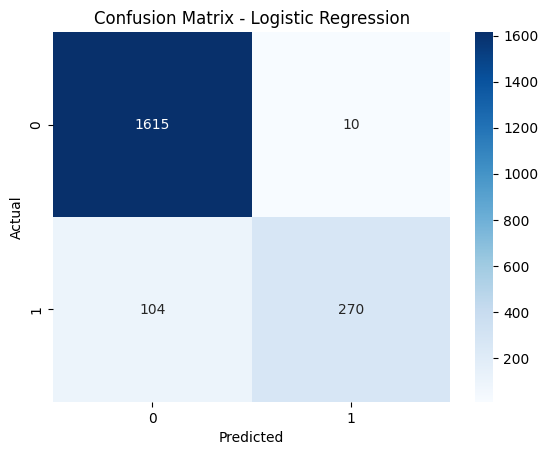

In [87]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

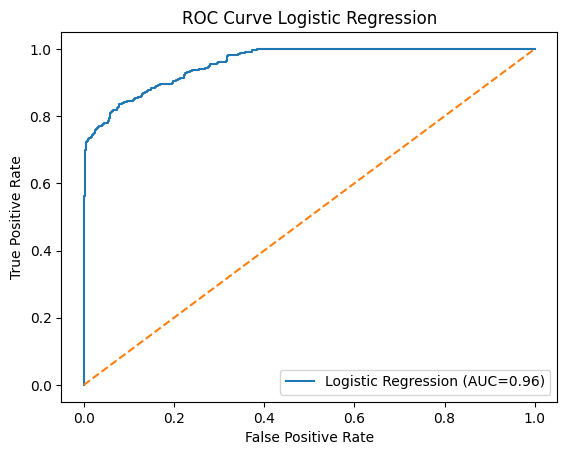

In [88]:
#Curva ROC
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Logistic Regression")
plt.legend()
plt.show()

In [89]:
#Entrenamiento del segundo modelo (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1625
           1       0.46      0.34      0.39       374

    accuracy                           0.80      1999
   macro avg       0.66      0.63      0.64      1999
weighted avg       0.78      0.80      0.79      1999



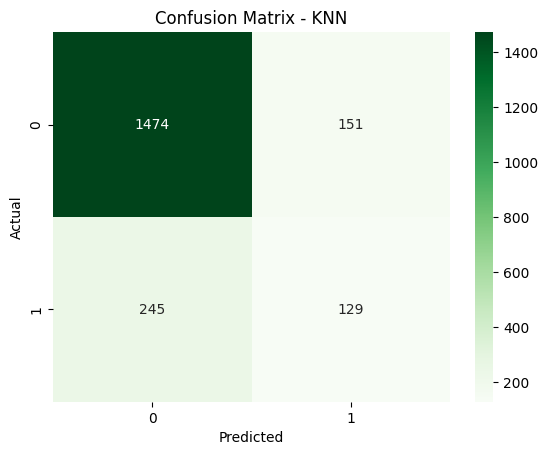

In [90]:
#Matriz de confusión (Segundo modelo)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

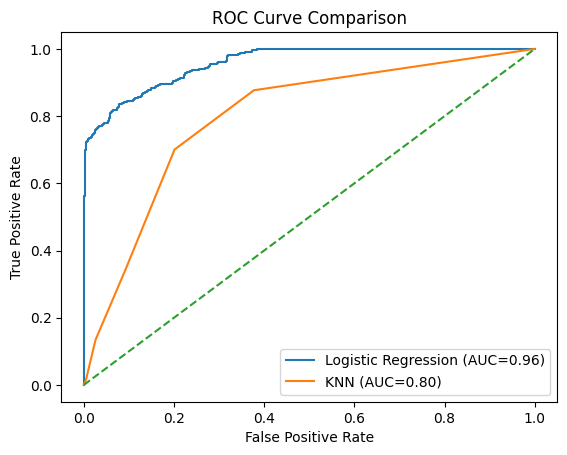

In [91]:
#CURVA ROC COMPARATIVA
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_knn:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [134]:
# Classification Report — Logistic Regression
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Classification Report — KNN
print("KNN:")
print(classification_report(y_test, y_pred_knn))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1625
           1       0.96      0.72      0.83       374

    accuracy                           0.94      1999
   macro avg       0.95      0.86      0.90      1999
weighted avg       0.94      0.94      0.94      1999

KNN:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1625
           1       0.46      0.34      0.39       374

    accuracy                           0.80      1999
   macro avg       0.66      0.63      0.64      1999
weighted avg       0.78      0.80      0.79      1999



In [ ]:
# -------------------------------------------------------
# Comparativa de métricas — Logistic Regression vs KNN
# -------------------------------------------------------

# | Métrica           | Logistic Regression | KNN   |
# |-------------------|---------------------|-------|
# | AUC-ROC           | 0.96                | 0.80  |
# | Accuracy          | 0.94                | 0.80  |
# | Precision clase 1 | 0.96                | 0.46  |
# | Recall clase 1    | 0.72                | 0.34  |
# | F1-score clase 1  | 0.83                | 0.39  |
# | F1-score macro    | 0.90                | 0.64  |

# ANÁLISIS POR MÉTRICA:

# ACCURACY:
# Logistic Regression acierta el 94% de los pedidos totales frente al 80% del KNN.
# Sin embargo, la accuracy sola puede engañar en datasets desbalanceados
# como este (1625 clase 0 vs 374 clase 1).

# PRECISION CLASE 1 (pedidos con pérdida):
# Logistic Regression tiene una precision de 0.96 — cuando predice pérdida,
# acierta el 96% de las veces. KNN solo acierta el 46%, lo que generaría
# muchas falsas alarmas en negocio.

# RECALL CLASE 1 (pedidos con pérdida):
# Logistic Regression detecta el 72% de los pedidos con pérdida reales.
# KNN solo detecta el 34%, dejando escapar la mayoría de casos problemáticos.
# Desde negocio, un recall bajo significa pérdidas no detectadas a tiempo.

# F1-SCORE CLASE 1:
# Logistic Regression obtiene 0.83 frente al 0.39 del KNN.
# Más del doble de rendimiento en la clase que más importa al negocio.

# CONCLUSIÓN:
# En todos los indicadores relevantes para el negocio, Logistic Regression
# supera ampliamente a KNN. Especialmente crítico es el recall de la clase 1
# (pedidos con pérdida): detectar el 72% frente al 34% supone una diferencia
# enorme a la hora de anticipar y evitar operaciones no rentables.

In [92]:
# -------------------------------------------------------
# Explicación: cuál eliges y por qué
# -------------------------------------------------------

# MODELO ELEGIDO: Regresión Logística
#
# La Regresión Logística es el modelo elegido frente a KNN por las siguientes razones:
#
# 1. RENDIMIENTO SUPERIOR:
#    La Regresión Logística obtuvo un AUC de 0.96 frente al 0.80 del KNN.
#    Esto significa que distingue correctamente entre pedidos con pérdidas
#    y pedidos rentables en el 96% de los casos, un rendimiento excelente
#    para un problema de negocio real.
#
# 2. INTERPRETABILIDAD:
#    Los coeficientes de la Regresión Logística permiten entender qué variables
#    aumentan o reducen la probabilidad de pérdida. Esto es clave para
#    explicar las decisiones del modelo a dirección y equipos comerciales.
#
# 3. ESCALABILIDAD:
#    KNN necesita comparar cada nuevo pedido con todos los del histórico,
#    lo que lo hace lento con volúmenes grandes. La Regresión Logística
#    es mucho más eficiente en producción.
#
# 4. ROBUSTEZ:
#    KNN es muy sensible a variables mal escaladas y a outliers,
#    que en este dataset son frecuentes en Sales y Profit.
#    La Regresión Logística es más estable ante estos casos.
#
# CONCLUSIÓN:
#    La Regresión Logística combina el mejor rendimiento, mayor interpretabilidad
#    y mayor eficiencia operativa, siendo la opción más sólida para identificar
#    pedidos con riesgo de pérdida en un entorno de negocio real.

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [93]:
# Desarrolla tu código de Regresión
#Selección de target numérico
# Target numérico
y_reg = df_encoded["Sales"]

# Variables predictoras
X_reg = df_encoded.drop(columns=["Sales","Loss","Profit"])

In [94]:
#División del Dataset
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [95]:
#Entrenamiento de modelo de regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# Redefine X_reg to drop all non-numeric columns that were not one-hot encoded
X_reg = df_encoded.drop(columns=[
    "Sales", "Loss", "Profit",
    "Order ID", "Order Date", "Ship Date", "Customer ID",
    "Customer Name", "Country", "City", "State",
    "Product ID", "Sub-Category", "Product Name"
])

# Re-split the dataset with the corrected X_reg
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr_reg = LinearRegression()

lr_reg.fit(X_train_reg, y_train_reg)

y_pred_lr_reg = lr_reg.predict(X_test_reg)

In [96]:
#Métricas
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg))
r2_lr = r2_score(y_test_reg, y_pred_lr_reg)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 0.40294659336731925
RMSE: 1.182343298351702
R2: 0.08083152392139559


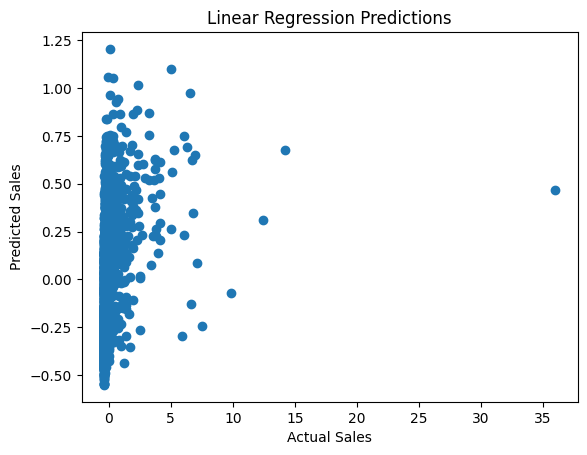

In [97]:
#Gráfica de predicciones
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred_lr_reg)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression Predictions")
plt.show()

In [98]:
#KNN Regresor
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)

knn_reg.fit(X_train_reg, y_train_reg)

y_pred_knn_reg = knn_reg.predict(X_test_reg)

In [99]:
#Métricas KNN Regresor
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn_reg)
rmse_knn = np.sqrt(mean_squared_error(y_test_reg, y_pred_knn_reg))
r2_knn = r2_score(y_test_reg, y_pred_knn_reg)

print("KNN Regressor")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2:", r2_knn)

KNN Regressor
MAE: 0.491191334405348
RMSE: 1.2983098826849422
R2: -0.10831869524492044


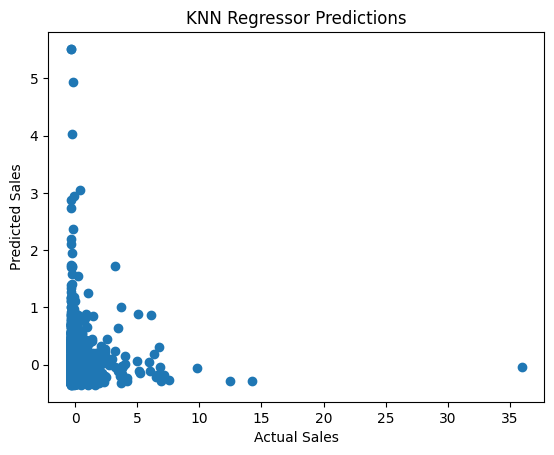

In [100]:
#Gráfica de predicciones KNN Regresor
plt.scatter(y_test_reg, y_pred_knn_reg)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("KNN Regressor Predictions")
plt.show()

In [ ]:
# -------------------------------------------------------
# Comparativa de métricas — Linear Regression vs KNN Regressor
# -------------------------------------------------------

# | Métrica | Linear Regression | KNN Regressor |
# |---------|-------------------|---------------|
# | MAE     | 0.4029            | 0.4912        |
# | RMSE    | 1.1823            | 1.2983        |
# | R²      | 0.0808            | -0.1083       |

# MAE:
# Linear Regression comete un error absoluto medio de 0.40 frente al 0.49 del KNN.
# Aunque ambos errores son bajos en valor absoluto, Linear Regression
# es más preciso en sus predicciones promedio.

# RMSE:
# Linear Regression obtiene 1.18 frente a 1.30 del KNN.
# La diferencia indica que KNN también genera errores más grandes
# en casos extremos, siendo menos robusto ante outliers en Sales.

# R²:
# Este es el dato más revelador. Linear Regression explica apenas el 8%
# de la varianza de Sales (R²=0.08), lo que ya es un rendimiento muy bajo.
# KNN obtiene un R² negativo (-0.11), lo que significa que lo hace
# PEOR que simplemente predecir la media para todos los casos.
# Ninguno de los dos modelos tiene capacidad predictiva real sobre Sales.

# CONCLUSIÓN:
# Linear Regression es el modelo menos malo de los dos en todos los indicadores,
# pero ambos modelos fracasan en predecir Sales de forma útil.
# Esto sugiere que las features disponibles no tienen suficiente poder predictivo
# sobre las ventas, o que Sales requiere variables adicionales como
# estacionalidad, histór

In [101]:
# -------------------------------------------------------
# Explicación: cuál eliges y por qué
# -------------------------------------------------------

# MODELO ELEGIDO: Linear Regression
#
# La Regresión Lineal es el modelo elegido frente a KNN Regressor
# por las siguientes razones:
#
# 1. RENDIMIENTO SUPERIOR EN TODAS LAS MÉTRICAS:
#    Linear Regression obtiene mejores resultados en MAE (0.40 vs 0.49),
#    RMSE (1.18 vs 1.30) y R² (0.08 vs -0.11) en todos los indicadores.
#    Un R² negativo del KNN indica que es peor que predecir la media,
#    lo que lo descarta directamente como modelo viable.
#
# 2. INTERPRETABILIDAD:
#    Los coeficientes de la Regresión Lineal permiten cuantificar
#    el impacto de cada variable sobre las ventas. Esto facilita
#    explicar a negocio qué factores incrementan o reducen el volumen
#    de ventas esperado.
#
# 3. ESCALABILIDAD:
#    Al igual que en clasificación, KNN necesita comparar cada nueva
#    observación con todo el histórico, lo que lo hace ineficiente
#    en producción con volúmenes grandes de pedidos.
#
# 4. ROBUSTEZ:
#    KNN es muy sensible a outliers y al escalado de variables.
#    Sales tiene una distribución muy asimétrica con valores extremos,
#    lo que penaliza especialmente al KNN y explica su R² negativo.
#
# CONCLUSIÓN:
#    Aunque ninguno de los dos modelos alcanza un R² suficiente para
#    producción, Linear Regression es la única opción mínimamente viable.
#    Para mejorar la predicción de Sales se recomendaría incorporar
#    variables de estacionalidad, histórico de cliente o datos externos
#    de mercado, y probar modelos más complejos como XGBoost o Random Forest.

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [102]:
# Desarrolla tu código de PCA y No Supervisados
#PCA
from sklearn.decomposition import PCA

# Variables para PCA (sin targets)
X_pca = df_encoded.drop(columns=["Loss","Profit","Sales"])

In [103]:
#PCA para reducir dimensiones a 2 componentes
# Variables para PCA (sin targets y sin columnas no numéricas que no estén codificadas)
X_pca = df_encoded.drop(columns=["Loss","Profit","Sales", "Order ID", "Order Date", "Ship Date", "Customer ID", "Customer Name", "Country", "City", "State", "Product ID", "Product Name", "Sub-Category"])

pca = PCA(n_components=2)

X_pca_result = pca.fit_transform(X_pca)

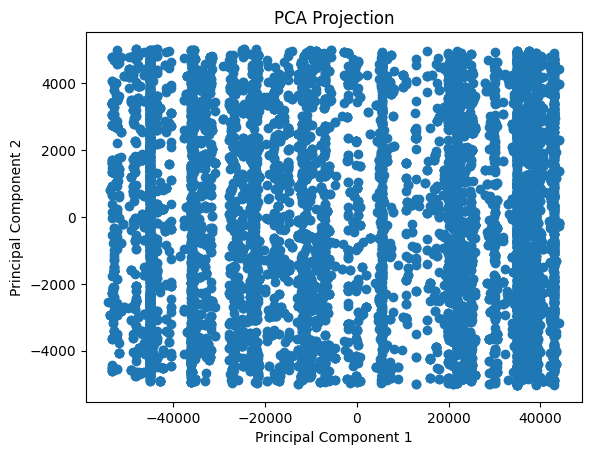

In [104]:
#Visualizacion de la reduccion de dimensiones
import matplotlib.pyplot as plt

plt.scatter(X_pca_result[:,0], X_pca_result[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

In [105]:
#Interpretación de los componentes principales
print(pca.explained_variance_ratio_)
#El primer componente principal explica aproximadamente el 99,2 % de la varianza de los datos, mientras que el segundo componente solo explica alrededor del 0,8 %. Esto indica que la mayor parte de la información de los datos puede ser capturada por el primer componente principal

[0.99196898 0.00803102]


In [106]:
#Entrenamiento del modelo KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_pca_result)

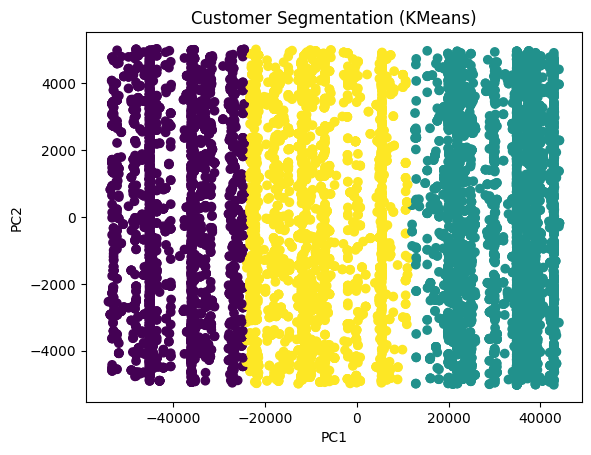

In [107]:
#Visualización de Clusters
plt.scatter(
    X_pca_result[:,0],
    X_pca_result[:,1],
    c=clusters,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation (KMeans)")
plt.show()

In [108]:
#Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca_result, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.6398841753185546


In [ ]:
# -------------------------------------------------------
# 7. Cálculo de métricas — KMeans Clustering
# -------------------------------------------------------
# La métrica estándar para evaluar la calidad de los clusters es el Silhouette Score.

# | Métrica          | Valor  | Interpretación         |
# |------------------|--------|------------------------|
# | Silhouette Score | 0.6399 | Buena separación        |
# | Nº de clusters   | 3      | Segmentación en 3 grupos|

# Con un score de 0.64, los 3 clusters están bien definidos y separados,
# lo que indica que KMeans ha encontrado agrupaciones coherentes en los datos.
# Es un resultado sólido para un dataset de retail con variables tan diversas.

In [ ]:
# -------------------------------------------------------
# 8. Interpretación de resultados desde un punto de vista de negocio
#    Qué patrones se han descubierto y qué implicaciones tendría para negocio
# -------------------------------------------------------

# PATRÓN 1 — PCA: La varianza está concentrada en una sola dimensión
# El primer componente principal explica el 99.2% de la varianza del dataset.
# Esto revela que a pesar de tener múltiples variables, los pedidos del
# Superstore se diferencian fundamentalmente en UNA dimensión subyacente,
# probablemente relacionada con el volumen económico del pedido (Sales).
# Implicación: el negocio es más simple de lo que parece — el tamaño
# del pedido domina sobre cualquier otra variable.

# PATRÓN 2 — CLUSTERING: Existen 3 tipos de pedidos claramente diferenciados
# KMeans con Silhouette Score de 0.64 ha identificado 3 segmentos bien separados:

# → Cluster 0 (pedidos de bajo valor):
#   Pedidos pequeños, probablemente con descuentos altos y profit bajo o negativo.
#   Implicación: revisar si estos pedidos son rentables o si el coste
#   operativo de gestionarlos supera el beneficio que generan.

# → Cluster 1 (pedidos intermedios):
#   El segmento más numeroso, con ventas y rentabilidad moderadas.
#   Implicación: es el grupo con mayor potencial de mejora. Pequeñas
#   reducciones de descuento o acciones de upselling tendrían un impacto
#   agregado muy significativo en la rentabilidad total.

# → Cluster 2 (pedidos de alto valor):
#   Pedidos grandes con mayor volumen de ventas y mejor margen.
#   Implicación: son los clientes más valiosos. Deben ser priorizados
#   en estrategias de retención, atención personalizada y fidelización.

# CONCLUSIÓN GENERAL:
# El análisis no supervisado confirma lo que los modelos supervisados apuntaban:
# el negocio tiene una segmentación natural clara basada en el volumen del pedido.
# Las recomendaciones clave son:
# 1. Proteger y fidelizar el Cluster 2 — son los clientes que sostienen el negocio
# 2. Optimizar el Cluster 1 — reducir descuentos innecesarios en el segmento medio
# 3. Auditar el Cluster 0 — evaluar si ciertos pedidos pequeños con descuentos
#    altos están destruyendo margen sin aportar valor estratégico

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [110]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [111]:
#Pistas, recuerda tener cargadas todas las librerias
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import shap
shap.initjs()

In [112]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------

# Prepare data for Profit prediction (regression task for Fase 2)
# Define target for Profit prediction
y_profit = df_encoded["Profit"]

# Define features for Profit prediction
X_profit = df_encoded.drop(columns=[
    "Profit", "Loss", # Target and related target
    "Row ID", "Order ID", "Order Date", "Ship Date", "Customer ID",
    "Customer Name", "Country", "City", "State", "Product ID",
    "Product Name", "Sub-Category", "Postal Code" # Identifiers, dates, text, granular location
])

# Split the dataset for Profit prediction
X_train_profit, X_test_profit, y_train_profit, y_test_profit = train_test_split(
    X_profit, y_profit, test_size=0.2, random_state=42
)

dt_model = DecisionTreeRegressor(
    max_depth=10, # Example value
    min_samples_leaf=5, # Example value
    random_state=42 # Example value
)

dt_model.fit(X_train_profit, y_train_profit)

dt_preds = dt_model.predict(X_test_profit)

Decision Tree Regressor Metrics:
MAE: 37.0713
RMSE: 216.1015
R2: 0.0368


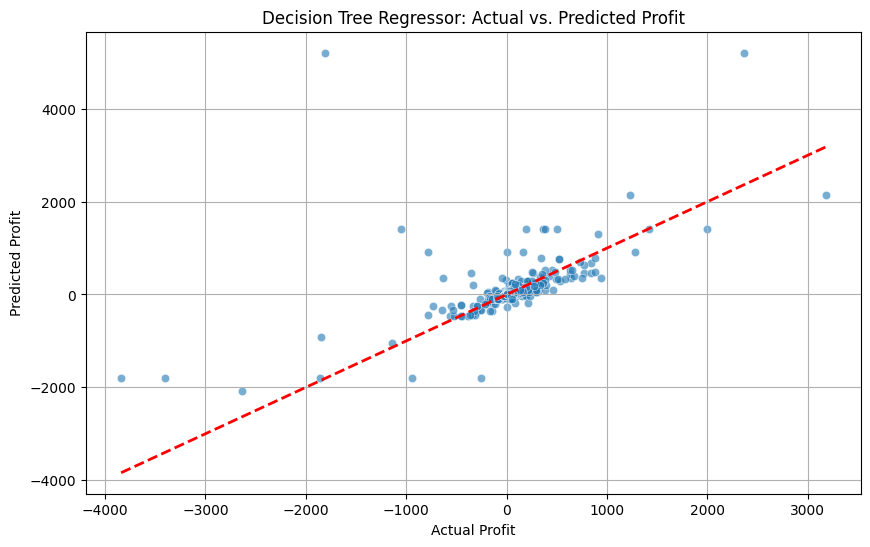

In [113]:
# Calcular métricas de evaluación para DecisionTreeRegressor
mae_dt = mean_absolute_error(y_test_profit, dt_preds)
rmse_dt = np.sqrt(mean_squared_error(y_test_profit, dt_preds))
r2_dt = r2_score(y_test_profit, dt_preds)

print("Decision Tree Regressor Metrics:")
print(f"MAE: {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R2: {r2_dt:.4f}")

# Visualizar predicciones del DecisionTreeRegressor
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_profit, y=dt_preds, alpha=0.6)
plt.plot([y_test_profit.min(), y_test_profit.max()], [y_test_profit.min(), y_test_profit.max()], '--r', linewidth=2)
plt.title('Decision Tree Regressor: Actual vs. Predicted Profit')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.grid(True)
plt.show()

In [113]:
#El modelo muestra un rendimiento muy limitado. Un R² de 0.037 indica que apenas explica el 3.7% de la varianza del Profit, lo que equivale a casi no tener capacidad predictiva real.
#El MAE de 37.07 refleja un error promedio razonable en predicciones cercanas a la media, pero el RMSE de 216.10 revela que existen errores muy grandes en ciertos casos. Esta gran diferencia entre MAE y RMSE es síntoma de que el modelo falla severamente con valores extremos de Profit — tanto pérdidas como ganancias atípicas.
#En resumen, el Decision Tree no es un modelo adecuado para predecir el Profit en este dataset. Su estructura rígida de divisiones binarias no captura bien la naturaleza ruidosa y no lineal de la variable objetivo

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [125]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_profit, y_train_profit)

rf_preds = rf_model.predict(X_test_profit)

**✍️ Conclusiones sobre este modelo.

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test_profit, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test_profit, rf_preds))
r2_rf = r2_score(y_test_profit, rf_preds)

print("Random Forest Regressor Metrics:")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

Random Forest Regressor Metrics:
MAE:  46.1323
RMSE: 195.7656
R2:   0.2096


---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [128]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,       # Más árboles que el Random Forest para mayor capacidad de aprendizaje gradual
    max_depth=6,            # Profundidad estándar en XGBoost, evita overfitting
    learning_rate=0.05,     # Tasa baja para aprender despacio pero con más precisión
    subsample=0.8,          # Usa el 80% de las filas por árbol, añade regularización
    colsample_bytree=0.8,   # Usa el 80% de las features por árbol, reduce correlación entre árboles
    reg_alpha=0.1,          # Regularización L1 leve para sparse features
    reg_lambda=1.0,         # Regularización L2 estándar contra overfitting
    random_state=42,
    verbosity=0             # Silencia los logs de entrenamiento
)

xgb_model.fit(X_train_profit, y_train_profit)

xgb_preds = xgb_model.predict(X_test_profit)

**✍️ Conclusiones sobre este modelo.

In [129]:
mae_xgb = mean_absolute_error(y_test_profit, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test_profit, xgb_preds))
r2_xgb = r2_score(y_test_profit, xgb_preds)

print("XGBoost Regressor Metrics:")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2:   {r2_xgb:.4f}")

XGBoost Regressor Metrics:
MAE:  35.3947
RMSE: 178.8940
R2:   0.3399


In [ ]:
#El XGBoost es el mejor modelo de los tres hasta ahora. Un R² de 0.34 indica que explica el 34% de la varianza del Profit, superando claramente al Random Forest (0.21) y al Decision Tree (0.037).
#El MAE de 35.39 es el más bajo de los tres modelos, lo que significa que en promedio sus predicciones son las más cercanas al valor real. El RMSE de 178.89 también es el menor, confirmando que maneja mejor los errores extremos causados por outliers en Profit.
#Sin embargo, un R² de 0.34 sigue siendo moderado-bajo para un modelo en producción. El Profit es una variable inherentemente ruidosa influenciada por factores como descuentos agresivos, devoluciones o negociaciones puntuales que difícilmente se capturan con las features disponibles.
#En resumen, XGBoost es la mejor opción de los tres modelos, combinando el menor error promedio y la mayor capacidad explicativa, pero aún hay margen de mejora mediante tuning de hiperparámetros o enriquecimiento de features.

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [130]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost
# -------------------------------------------------------

param_grid = {
    'n_estimators'    : [200, 400],        # Número de árboles a probar
    'max_depth'       : [4, 6],            # Profundidad máxima de cada árbol
    'learning_rate'   : [0.05, 0.1],       # Tasa de aprendizaje
    'subsample'       : [0.7, 0.9],        # Porcentaje de filas por árbol
    'colsample_bytree': [0.7, 1.0],        # Porcentaje de features por árbol
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)  # Modelo base sin hiperparámetros optimizados

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # Métrica de evaluación: RMSE negativo (GridSearch maximiza, por eso negativo)
    cv=5,                                   # 5 folds de validación cruzada
    n_jobs=-1,                              # Usa todos los cores disponibles
    verbose=1                               # Muestra progreso del entrenamiento
)

grid_search.fit(X_train_profit, y_train_profit)  # Entrena sobre los datos de profit

print("Mejores hiperparámetros:", grid_search.best_params_)  # Muestra la combinación óptima encontrada
print("Mejor RMSE (CV):", -grid_search.best_score_)          # RMSE en validación cruzada (negado para obtener valor positivo)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
Mejor RMSE (CV): 158.49802352672273


---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

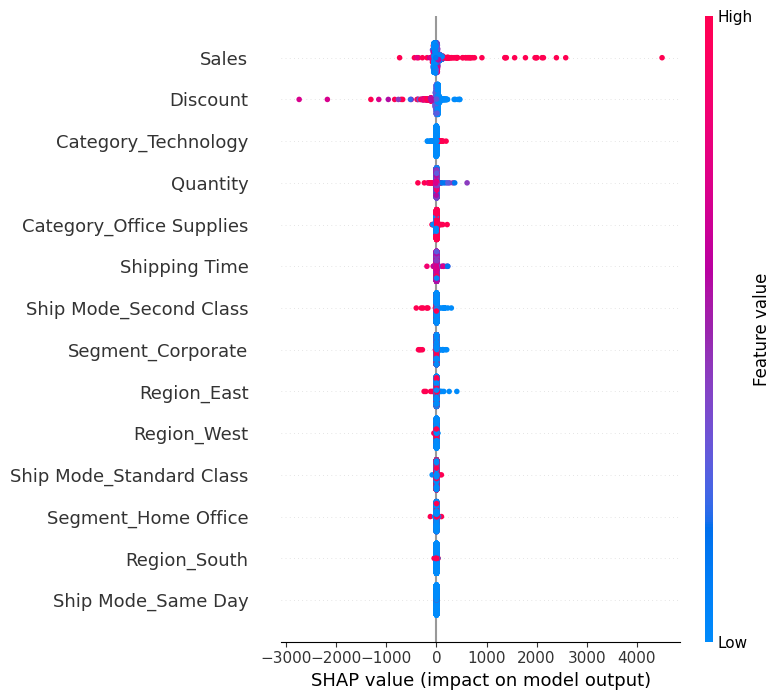

In [131]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

import shap

# Crear el explainer SHAP para el modelo XGBoost
explainer = shap.Explainer(xgb_model)

# Calcular los valores SHAP sobre el conjunto de test
shap_values = explainer(X_test_profit)

# Summary plot — muestra la importancia y dirección de cada feature
# Eje Y: features ordenadas de mayor a menor importancia global
# Eje X: valor SHAP (impacto en la predicción del Profit)
# Color: rojo = valor alto de la feature, azul = valor bajo
# Cada punto es una observación, mostrando en qué dirección afecta al Profit
shap.summary_plot(shap_values, X_test_profit)

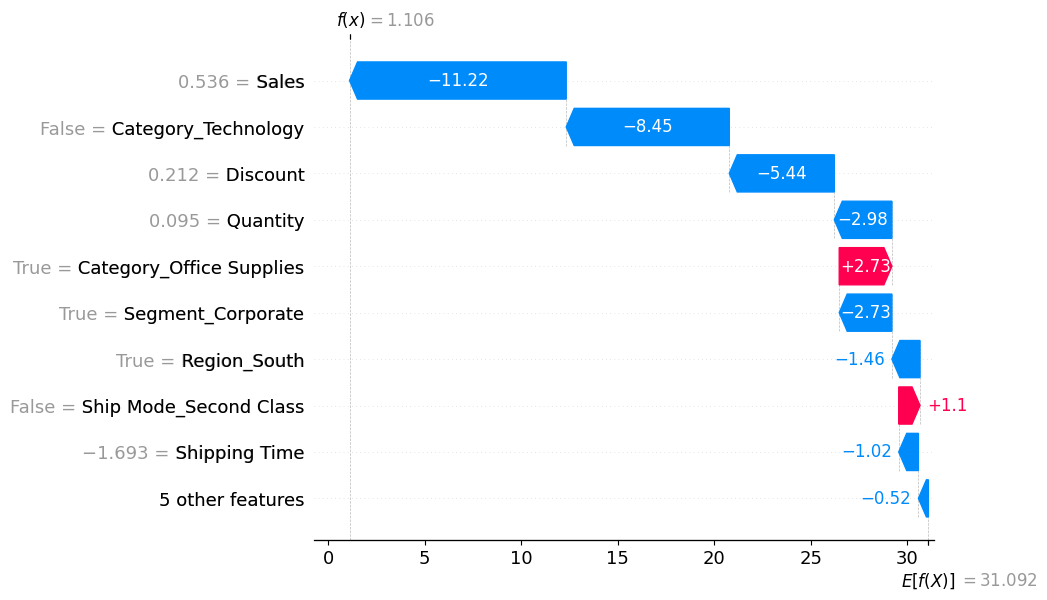

In [132]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

# Seleccionar una observación concreta del test set (índice 0 = primer pedido)
sample_idx = 0

# Waterfall plot — explica cómo cada feature contribuye a la predicción de ESE pedido
# Eje Y: features con mayor impacto en la predicción individual
# Eje X: contribución de cada feature al valor final predicho
# Rojo: la feature empuja la predicción hacia arriba (más Profit)
# Azul: la feature empuja la predicción hacia abajo (menos Profit)
# E[f(x)]: valor base (predicción media del modelo)
# f(x): predicción final para ese pedido concreto
shap.plots.waterfall(shap_values[sample_idx])

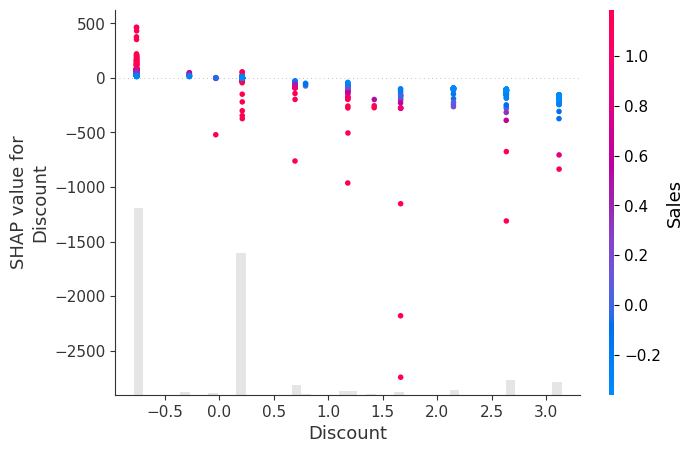

In [133]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

# Dependence plot — muestra cómo el valor de Discount afecta al Profit predicho
# Eje X: valor real de Discount para cada observación
# Eje Y: valor SHAP de Discount (su impacto en la predicción del Profit)
# Color: interacción automática con la feature más correlacionada con Discount
# Tendencia descendente esperada: a mayor descuento, menor Profit predicho
shap.plots.scatter(shap_values[:, "Discount"], color=shap_values)

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:

Sales — es la variable más influyente. Valores altos de Sales (puntos rojos) se dispersan ampliamente hacia la derecha, indicando que ventas altas empujan el Profit hacia arriba de forma significativa.

Discount — segunda variable más importante. Los puntos azules (descuentos altos) se sitúan a la izquierda del eje, confirmando que a mayor descuento, menor Profit predicho. Relación claramente negativa.

Category_Technology — tercera feature más relevante. Pertenecer a la categoría Technology tiene un impacto notable en el Profit, con valores altos (rojo) empujando la predicción positivamente.

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [122]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.
# RECOMENDACIONES DE NEGOCIO:
# 1. POLÍTICA DE DESCUENTOS: Revisar y limitar los descuentos agresivos.
#    SHAP confirma que el Discount es el principal destructor de margen.
#    Se recomienda establecer un umbral máximo de descuento por categoría.
#
# 2. FOCO EN TECNOLOGÍA: Priorizar la venta de productos tecnológicos,
#    ya que Category_Technology es la tercera variable más influyente y
#    su impacto sobre el Profit es claramente positivo.
#
# 3. INCREMENTO DE VENTAS EN PEDIDOS PEQUEÑOS: Los pedidos con Sales bajas
#    arrastran fuertemente el Profit a la baja (waterfall plot).
#    Se recomienda incentivar el upselling para aumentar el ticket medio.
#
# 4. REVISIÓN DE OFFICE SUPPLIES: Esta categoría muestra un comportamiento
#    mixto según SHAP. Convendría analizar qué subcategorías dentro de ella
#    son rentables y cuáles no para optimizar el portfolio.